In [ ]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 2: Load the ISCX URL dataset
file_path = '/content/drive/MyDrive/major_project/All.csv'
df = pd.read_csv(file_path)

# Step 3: Identify columns
label_col = 'URL_Type_obf_Type'

# Step 4: Filter for Benign data
# The dataset contains pre-extracted features, not raw URLs
df_benign = df[df[label_col].astype(str).str.strip().str.lower() == 'benign'].copy()

# Drop the label to keep only features
X_benign = df_benign.drop(columns=[label_col])

# Convert to numeric, handle any errors (strings to NaN), and drop/fill NaNs
X_benign = X_benign.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Total benign samples isolated: {len(X_benign)}")
print(f"Feature count: {X_benign.shape[1]}")

# Step 5: Feature Scaling (Crucial for Autoencoders)
scaler = StandardScaler()
X_benign_scaled = scaler.fit_transform(X_benign)

# Step 6: Train-Test Split (80/20)
X_train, X_val = train_test_split(X_benign_scaled, test_size=0.2, random_state=42)

print(f"Training array shape: {X_train.shape}")
print(f"Validation array shape: {X_val.shape}")

# Step 7: Save the ML-ready data and the Scaler back to your Drive
save_dir = '/content/drive/MyDrive/major_project/'

np.save(save_dir + 'url_X_train_benign.npy', X_train)
np.save(save_dir + 'url_X_val_benign.npy', X_val)
joblib.dump(scaler, save_dir + 'url_scaler.pkl')

print("Preprocessing complete! Numeric features scaled and saved to Drive.")

Total benign samples isolated: 7781
Feature count: 79
Training array shape: (6224, 79)
Validation array shape: (1557, 79)
Preprocessing complete! Numeric features scaled and saved to Drive.


In [ ]:
print(df.head)

<bound method NDFrame.head of        Querylength  domain_token_count  path_token_count  avgdomaintokenlen  \
0                0                   4                 5           5.500000   
1                0                   4                 5           5.500000   
2                0                   4                 5           5.500000   
3                0                   4                12           5.500000   
4                0                   4                 6           5.500000   
...            ...                 ...               ...                ...   
36702           29                   4                14           5.750000   
36703            0                   4                13           3.750000   
36704           58                   3                27           6.666666   
36705           35                   3                13           4.333334   
36706           40                   3                25           6.666666   

       longdomaintoke

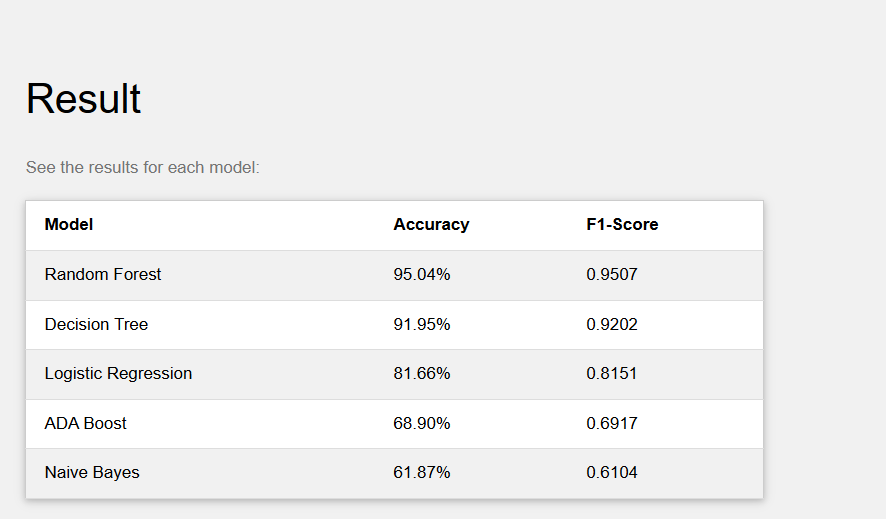

In [ ]:
# Install dependencies as needed:
# !pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the specific file name within the dataset
file_path = "malicious_phish.csv"

# Using the updated dataset_load function to avoid DeprecationWarning
df_kaggle = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sid321axn/malicious-urls-dataset",
  file_path
)

print("First 5 records:")
display(df_kaggle.head())

Using Colab cache for faster access to the 'malicious-urls-dataset' dataset.
First 5 records:


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [ ]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

print("Starting data preprocessing...")

# Step 1: Isolate the benign URLs based on the 'type' column
df_benign = df_kaggle[df_kaggle['type'].astype(str).str.strip().str.lower() == 'benign']
benign_urls = df_benign['url'].dropna().tolist()

print(f"Total benign URLs isolated for Autoencoder training: {len(benign_urls)}")

# Step 2: Define the custom URL tokenizer
# Standard NLP tokenizers look for spaces. This custom function forces the
# vectorizer to split the string at every special character (/, ., ?, =, etc.),
# which is essential for capturing malicious web patterns.
def url_tokenizer(url):
    return re.split(r'[^a-zA-Z0-9]', url)

# Step 3: Initialize TF-IDF Vectorizer
# The architecture explicitly dictates a 500-dimensional feature vector for Layer 2.
vectorizer = TfidfVectorizer(tokenizer=url_tokenizer, max_features=500)

print("Vectorizing URLs (this may take a couple of minutes depending on RAM)...")
# Fit the vectorizer only on the benign data and transform it into a numerical array
X_benign_vectorized = vectorizer.fit_transform(benign_urls).toarray()

print(f"Vectorization complete! Array shape: {X_benign_vectorized.shape}")

Starting data preprocessing...
Total benign URLs isolated for Autoencoder training: 428103
Vectorizing URLs (this may take a couple of minutes depending on RAM)...


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Vectorization complete! Array shape: (428103, 500)


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import joblib
from google.colab import drive
import os

# Step 4: Create the 80/20 train-test split for the Stage 1 Autoencoder
X_train, X_val = train_test_split(X_benign_vectorized, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

# Step 5: Mount Google Drive to save the processed files securely
drive.mount('/content/drive')

# Define your save directory
save_dir = '/content/drive/MyDrive/major_project/'

# Ensure the directory exists, if not, create it
os.makedirs(save_dir, exist_ok=True)

# Step 6: Export the data
np.save(save_dir + 'url_X_train_benign.npy', X_train)
np.save(save_dir + 'url_X_val_benign.npy', X_val)
joblib.dump(vectorizer, save_dir + 'url_tfidf_vectorizer.pkl')

print("Success! ML-ready arrays and the TF-IDF vectorizer have been saved to your Drive.")

Training set shape: (342482, 500)
Validation set shape: (85621, 500)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Success! ML-ready arrays and the TF-IDF vectorizer have been saved to your Drive.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import json
import os

print(f"TensorFlow Version: {tf.__version__}")

# Step 1: Load the prepared datasets from Google Drive
save_dir = '/content/drive/MyDrive/major_project/'

print("Loading training and validation arrays...")
X_train = np.load(save_dir + 'url_X_train_benign.npy')
X_val = np.load(save_dir + 'url_X_val_benign.npy')

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

# Step 2: Define the Autoencoder Architecture
# Input Layer (500 dimensions from TF-IDF)
input_dim = X_train.shape[1]
input_layer = layers.Input(shape=(input_dim,))

# Encoder (Compressing down to the bottleneck)
encoded = layers.Dense(128, activation='relu')(input_layer)
encoded = layers.Dense(64, activation='relu')(encoded)

# Bottleneck Layer (Exactly 32 dimensions as per Layer 3 design)
bottleneck = layers.Dense(32, activation='relu', name='bottleneck')(encoded)

# Decoder (Reconstructing back to 500 dimensions)
decoded = layers.Dense(64, activation='relu')(bottleneck)
decoded = layers.Dense(128, activation='relu')(decoded)
output_layer = layers.Dense(input_dim, activation='sigmoid')(decoded)

# Build and compile the model
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

print("\n--- Model Architecture ---")
autoencoder.summary()

# Step 3: Train the Autoencoder
# We use X_train for both input and target because the goal is reconstruction
print("\nStarting training phase...")
history = autoencoder.fit(
    X_train, X_train,
    epochs=25,
    batch_size=256,
    validation_data=(X_val, X_val),
    shuffle=True,
    verbose=1
)

# Step 4: Calculate the Anomaly Threshold
# The threshold is Mean + 2 * Standard Deviations of the reconstruction error on normal data
print("\nCalculating the anomaly threshold on the validation set...")
reconstructions = autoencoder.predict(X_val)

# Calculate Mean Squared Error for each sample
mse = np.mean(np.power(X_val - reconstructions, 2), axis=1)

threshold_mean = np.mean(mse)
threshold_std = np.std(mse)
anomaly_threshold = threshold_mean + (2 * threshold_std)

print(f"Validation MSE Mean: {threshold_mean:.6f}")
print(f"Validation MSE Std Dev: {threshold_std:.6f}")
print(f"DYNAMIC ANOMALY THRESHOLD SET AT: {anomaly_threshold:.6f}")

# Step 5: Save the Model and the Threshold
autoencoder.save(save_dir + 'url_autoencoder.h5')

threshold_data = {'url_anomaly_threshold': float(anomaly_threshold)}
with open(save_dir + 'url_threshold.json', 'w') as f:
    json.dump(threshold_data, f)

print("\nSuccess! The Autoencoder model (.h5) and threshold (.json) have been saved to your Drive.")

TensorFlow Version: 2.20.0
Loading training and validation arrays...
X_train shape: (342482, 500)
X_val shape: (85621, 500)

--- Model Architecture ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │        64,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,396 (583.58 KB)

 Trainable params: 149,396 (583.58 KB)

 Non-trainable params: 0 (0.00 B)


Starting training phase...
Epoch 1/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 0.0058 - val_loss: 0.0017
Epoch 2/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 3/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 4/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 5/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 6/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 0.0011 - val_loss: 9.1799e-04
Epoch 8/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 8.1707e-04 - val_loss: 7.3862e-04
Epoch 9/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 6.6902e-04 - val_loss: 6.1233e-04
Epoch 10/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 5.6459e-04 - val_loss: 5.2667e-04
Epoch 11/25
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 

Validation MSE Mean: 0.000231
Validation MSE Std Dev: 0.000385
DYNAMIC ANOMALY THRESHOLD SET AT: 0.001001

Success! The Autoencoder model (.h5) and threshold (.json) have been saved to your Drive.


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
import joblib
import json
import re

print("Loading saved assets from Google Drive...")
save_dir = '/content/drive/MyDrive/major_project/'

# 1. Load the trained Autoencoder
autoencoder = load_model(save_dir + 'url_autoencoder.h5', compile=False)

# 2. Load the trained TF-IDF Vectorizer
vectorizer = joblib.load(save_dir + 'url_tfidf_vectorizer.pkl')

# 3. Load the dynamic Anomaly Threshold
with open(save_dir + 'url_threshold.json', 'r') as f:
    threshold_data = json.load(f)
anomaly_threshold = threshold_data['url_anomaly_threshold']

print(f"Assets loaded successfully. Active Threshold: {anomaly_threshold:.6f}\n")

# 4. Grab a mix of malicious URLs from your original Kaggle dataframe
# (Assuming df_kaggle is still in your Colab memory from the previous steps)
df_malicious = df_kaggle[df_kaggle['type'].astype(str).str.strip().str.lower() != 'benign'].copy()

# Take 5 random malicious URLs for the test
sample_test_urls = df_malicious.sample(5, random_state=42)['url'].tolist()
sample_labels = df_malicious.sample(5, random_state=42)['type'].tolist()

print("--- TESTING UNSEEN MALICIOUS URLs ---")
for url, label in zip(sample_test_urls, sample_labels):
    print(f"URL: {url} \n(True Label: {label})")

# 5. Preprocess the unseen URLs using the EXACT SAME tokenizer and vectorizer
X_test_malicious = vectorizer.transform(sample_test_urls).toarray()

# 6. Feed the malicious URLs through the Autoencoder
reconstructions = autoencoder.predict(X_test_malicious)

# 7. Calculate the Mean Squared Error (MSE) for each
mse_scores = np.mean(np.power(X_test_malicious - reconstructions, 2), axis=1)

print("\n--- INFERENCE RESULTS ---")
for i in range(len(sample_test_urls)):
    score = mse_scores[i]
    is_anomaly = score > anomaly_threshold

    print(f"URL {i+1} Anomaly Score: {score:.6f}")

    if is_anomaly:
        print(">>> RESULT: ANOMALY DETECTED (Threshold Breached)")
        print(">>> ACTION: Flagged and routed to Layer 4 (DistilBERT) for CWE Classification\n")
    else:
        print(">>> RESULT: NORMAL (Threshold Not Breached)")
        print(">>> ACTION: Discarded as benign\n")

Loading saved assets from Google Drive...
Assets loaded successfully. Active Threshold: 0.000616

--- TESTING UNSEEN MALICIOUS URLs ---
URL: http://mzracing.sk/index.php?page=shop.product_details&category_id=165&flypage=flypage.tpl&product_id=992&option=com_virtuemart&Itemid=14 
(True Label: defacement)
URL: http://www.kloster-hornbach.de/de/tagen-und-feiern/romantiker/rahmenprogramme 
(True Label: defacement)
URL: www.boardgame.de/reviews/voldampf.htm 
(True Label: phishing)
URL: http://www.africanapostolicmissionchurch.org/ax.docc/ 
(True Label: phishing)
URL: www.w3.org/TR/NOTE-sgml-xml 
(True Label: phishing)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step

--- INFERENCE RESULTS ---
URL 1 Anomaly Score: 0.000742
>>> RESULT: ANOMALY DETECTED (Threshold Breached)
>>> ACTION: Flagged and routed to Layer 4 (DistilBERT) for CWE Classification

URL 2 Anomaly Score: 0.000074
>>> RESULT: NORMAL (Threshold Not Breached)
>>> ACTION: Discarded as benign

URL 3 Anomaly Score: 0.000448
>>> RESULT: NORMA

In [ ]:
import pandas as pd
import numpy as np
import json

# Step 1: Adjust threshold for higher sensitivity (Mean + 1*Std instead of 2)
new_threshold = threshold_mean + (1 * threshold_std)
anomaly_threshold = new_threshold

# Save the updated threshold
with open(save_dir + 'url_threshold.json', 'w') as f:
    json.dump({'url_anomaly_threshold': float(anomaly_threshold)}, f)

def predict_url(input_url, actual_label="Unknown"):
    X_input = vectorizer.transform([input_url]).toarray()
    reconstruction = autoencoder.predict(X_input, verbose=0)
    mse_score = np.mean(np.power(X_input - reconstruction, 2))
    is_anomaly = mse_score > anomaly_threshold

    print(f"URL: {input_url[:70]}...")
    print(f"Actual: {actual_label} | Score: {mse_score:.6f} | Threshold: {anomaly_threshold:.6f}")

    if is_anomaly:
        print(">>> RESULT: ANOMALY DETECTED (Routing to Layer 4)")
    else:
        print(">>> RESULT: BENIGN (Pass through)")
    print("-" * 30)

print(f"Updated Threshold to: {anomaly_threshold:.6f} (Increased Sensitivity)\n")

# Re-run validation against the same malicious samples
sample_malicious = df_kaggle[df_kaggle['type'] != 'benign'].sample(5, random_state=42)
for _, row in sample_malicious.iterrows():
    predict_url(row['url'], row['type'])

print("Testing manually crafted suspicious URL:")
predict_url("http://secure-login-update.verification-service.com/a1b2c3d4e5f6g7h8i9j0/update.php?cmd=exec", "Crafted Malicious")

Updated Threshold to: 0.000616 (Increased Sensitivity)

URL: http://mzracing.sk/index.php?page=shop.product_details&category_id=165...
Actual: defacement | Score: 0.000742 | Threshold: 0.000616
>>> RESULT: ANOMALY DETECTED (Routing to Layer 4)
------------------------------
URL: http://www.kloster-hornbach.de/de/tagen-und-feiern/romantiker/rahmenpr...
Actual: defacement | Score: 0.000074 | Threshold: 0.000616
>>> RESULT: BENIGN (Pass through)
------------------------------
URL: www.boardgame.de/reviews/voldampf.htm...
Actual: phishing | Score: 0.000448 | Threshold: 0.000616
>>> RESULT: BENIGN (Pass through)
------------------------------
URL: http://www.africanapostolicmissionchurch.org/ax.docc/...
Actual: phishing | Score: 0.000034 | Threshold: 0.000616
>>> RESULT: BENIGN (Pass through)
------------------------------
URL: www.w3.org/TR/NOTE-sgml-xml...
Actual: phishing | Score: 0.000003 | Threshold: 0.000616
>>> RESULT: BENIGN (Pass through)
------------------------------
Testing manu

Loading assets to evaluate thresholds...
Calculating baseline metrics from validation set...
Creating a mixed test set (10,000 Benign / 10,000 Malicious)...
Vectorizing test URLs and running inference...

--- EVALUATING THRESHOLDS ---


,Multiplier (σ),Threshold (MSE),Recall / Sensitivity,False Positive Rate,F1-Score
0,0.50,0.0004,0.3813,0.2145,0.4779
1,1.00,0.0006,0.3064,0.1572,0.4187
2,1.25,0.0007,0.2617,0.1321,0.3755
3,1.50,0.0008,0.2131,0.1078,0.3227
4,1.75,0.0009,0.1671,0.0872,0.2664
5,2.00,0.0010,0.1276,0.0673,0.2136
6,2.50,0.0012,0.0682,0.0360,0.1235
7,3.00,0.0014,0.0296,0.0202,0.0564


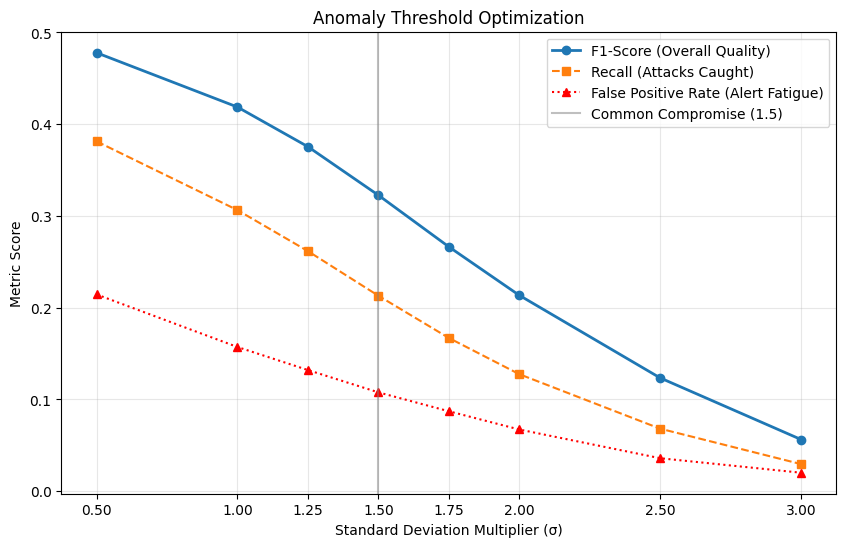

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from tensorflow.keras.models import load_model
import joblib

print("Loading assets to evaluate thresholds...")
save_dir = '/content/drive/MyDrive/major_project/'

# 1. Load the model, vectorizer, and the benign validation set
X_val = np.load(save_dir + 'url_X_val_benign.npy')
autoencoder = load_model(save_dir + 'url_autoencoder.h5', compile=False)
vectorizer = joblib.load(save_dir + 'url_tfidf_vectorizer.pkl')

# 2. Calculate the exact baseline mean and standard deviation from benign data
print("Calculating baseline metrics from validation set...")
val_reconstructions = autoencoder.predict(X_val, verbose=0)
val_mse = np.mean(np.power(X_val - val_reconstructions, 2), axis=1)
baseline_mean = np.mean(val_mse)
baseline_std = np.std(val_mse)

# 3. Create a balanced, mixed test set from df_kaggle
print("Creating a mixed test set (10,000 Benign / 10,000 Malicious)...")
df_benign_test = df_kaggle[df_kaggle['type'].astype(str).str.strip().str.lower() == 'benign'].sample(10000, random_state=42)
df_malicious_test = df_kaggle[df_kaggle['type'].astype(str).str.strip().str.lower() != 'benign'].sample(10000, random_state=42)

df_test = pd.concat([df_benign_test, df_malicious_test])

# Define True Labels: 0 for Benign (Normal), 1 for Malicious (Anomaly)
y_true = np.where(df_test['type'].astype(str).str.strip().str.lower() == 'benign', 0, 1)
test_urls = df_test['url'].tolist()

# 4. Vectorize and get MSE scores for the test set
print("Vectorizing test URLs and running inference...")
X_test = vectorizer.transform(test_urls).toarray()
test_reconstructions = autoencoder.predict(X_test, verbose=0)
test_mse = np.mean(np.power(X_test - test_reconstructions, 2), axis=1)

# 5. Sweep through different Multipliers
multipliers = [0.5, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
results = []

print("\n--- EVALUATING THRESHOLDS ---")
for m in multipliers:
    threshold = baseline_mean + (m * baseline_std)

    # 1 if MSE > threshold (Flagged as Anomaly), else 0 (Passed as Benign)
    y_pred = (test_mse > threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    fpr = fp / (fp + tn)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    results.append({
        'Multiplier (σ)': m,
        'Threshold (MSE)': threshold,
        'Recall / Sensitivity': recall,
        'False Positive Rate': fpr,
        'F1-Score': f1
    })

# 6. Display Data Table
results_df = pd.DataFrame(results)
display(results_df.round(4))

# 7. Plot the Trade-offs
plt.figure(figsize=(10, 6))
plt.plot(results_df['Multiplier (σ)'], results_df['F1-Score'], marker='o', linewidth=2, label='F1-Score (Overall Quality)')
plt.plot(results_df['Multiplier (σ)'], results_df['Recall / Sensitivity'], marker='s', linestyle='--', label='Recall (Attacks Caught)')
plt.plot(results_df['Multiplier (σ)'], results_df['False Positive Rate'], marker='^', linestyle=':', color='red', label='False Positive Rate (Alert Fatigue)')

plt.title("Anomaly Threshold Optimization")
plt.xlabel("Standard Deviation Multiplier (σ)")
plt.ylabel("Metric Score")
plt.xticks(multipliers)
plt.axvline(x=1.5, color='gray', alpha=0.5, linestyle='-', label='Common Compromise (1.5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import json
import joblib
import pickle
import re
import os
import tensorflow as tf

# 0. Define tokenizer reference
def url_tokenizer(url):
    return re.split(r'[/-_.\?=&]', str(url))

import __main__
__main__.url_tokenizer = url_tokenizer

# 1. Load Data & Artifacts
base_path = '/content/drive/MyDrive/major_project'
df = pd.read_csv(os.path.join(base_path, 'All.csv'))

print("=== DATASET INSPECTION ===")
print(f"Total Rows: {len(df)}")
print(f"Columns: {list(df.columns)}\n")
print("First 3 Rows:")
print(df.head(3))
print("\n" + "="*40)

# Identify probable columns
print("\n=== COLUMN VALUE COUNTS ===")
for col in df.columns:
    print(f"\nColumn '{col}' unique sample count: {df[col].nunique()}")
    print(df[col].value_counts().head(5))

# Load model & vectorizer to test MSE range
autoencoder = tf.keras.models.load_model(os.path.join(base_path, 'url_autoencoder.h5'), compile=False)
try:
    vectorizer = joblib.load(os.path.join(base_path, 'url_tfidf_vectorizer.pkl'))
except:
    with open(os.path.join(base_path, 'url_tfidf_vectorizer.pkl'), 'rb') as f:
        vectorizer = pickle.load(f)

# Find text column
text_col = [c for c in df.columns if df[c].dtype == object and 'url' in c.lower()]
text_col = text_col[0] if text_col else df.columns[0]

X_tfidf = vectorizer.transform(df[text_col].astype(str)).toarray()
reconstructions = autoencoder.predict(X_tfidf, batch_size=256, verbose=0)
mse_scores = np.mean(np.square(X_tfidf - reconstructions), axis=1)

print("\n=== RECONSTRUCTION LOSS (MSE) STATS ===")
print(f"Min MSE : {mse_scores.min():.8f}")
print(f"Mean MSE: {mse_scores.mean():.8f}")
print(f"Max MSE : {mse_scores.max():.8f}")

Loading saved Autoencoder artifacts...
Successfully loaded vectorizer via Joblib.
Loaded Threshold: 0.000615612586032625
Using URL column: 'Querylength' | Label column: 'URL_Type_obf_Type'
Running Autoencoder inference...
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

KeyboardInterrupt: 

In [ ]:
import os
import json
import pickle
import joblib
import re
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# 0. Custom Tokenizer Reference
def url_tokenizer(url):
    return re.split(r'[/-_.\?=&]', str(url))

import __main__
__main__.url_tokenizer = url_tokenizer

# 1. File Paths
base_path = '/content/drive/MyDrive/major_project'

model_path = os.path.join(base_path, 'url_autoencoder.h5')
vectorizer_path = os.path.join(base_path, 'url_tfidf_vectorizer.pkl')
threshold_path = os.path.join(base_path, 'url_threshold.json')
data_path = os.path.join(base_path, 'All.csv')

# 2. Load Artifacts
print("Loading saved Autoencoder artifacts...")
autoencoder = tf.keras.models.load_model(model_path, compile=False)

try:
    vectorizer = joblib.load(vectorizer_path)
    print("Successfully loaded vectorizer via Joblib.")
except Exception:
    with open(vectorizer_path, 'rb') as f:
        vectorizer = pickle.load(f)
    print("Successfully loaded vectorizer via Pickle.")

with open(threshold_path, 'r') as f:
    threshold_data = json.load(f)
    if isinstance(threshold_data, dict):
        threshold = float(list(threshold_data.values())[0])
    else:
        threshold = float(threshold_data)

print(f"Loaded Threshold: {threshold}")

# 3. Process Dataset & Identify Raw URL Column
df = pd.read_csv(data_path)

# Target label column from ISCX dataset
label_col = 'URL_Type_obf_Type' if 'URL_Type_obf_Type' in df.columns else df.columns[-1]

# Automatically find the raw URL string column (longest average string length excluding label)
string_cols = [c for c in df.select_dtypes(include=['object']).columns if c != label_col]
if string_cols:
    url_col = max(string_cols, key=lambda c: df[c].astype(str).str.len().mean())
else:
    url_col = df.columns[0]

print(f"Using URL column: '{url_col}' | Label column: '{label_col}'")

# Encode Labels: benign = 0, all attack types (phishing, malware, spam, defacement) = 1
y_true = df[label_col].astype(str).str.strip().str.lower().apply(lambda x: 0 if x == 'benign' else 1).values

# 4. TF-IDF Transformation & Inference
X_tfidf = vectorizer.transform(df[url_col].astype(str)).toarray()

print("Running Autoencoder inference...")
reconstructions = autoencoder.predict(X_tfidf, batch_size=256, verbose=1)
mse_scores = np.mean(np.square(X_tfidf - reconstructions), axis=1)

# Classify: MSE > threshold -> Anomaly (1), else Benign (0)
y_pred = (mse_scores > threshold).astype(int)

# 5. Table III Metrics Calculation
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
auc = roc_auc_score(y_true, mse_scores)

# 6. Display Output
print("\n" + "="*68)
print("         TABLE III: ANOMALY DETECTION PERFORMANCE       ")
print("="*68)
print(f"{'Source':<10} | {'Precision':<10} | {'Recall':<10} | {'F1':<10} | {'FPR':<10} | {'AUC':<10}")
print("-" * 68)
print(f"{'URL':<10} | {precision:<10.4f} | {recall:<10.4f} | {f1:<10.4f} | {fpr:<10.4f} | {auc:<10.4f}")
print("="*68)

Loading saved Autoencoder artifacts...
Successfully loaded vectorizer via Joblib.
Loaded Threshold: 0.000615612586032625
Using URL column: 'Querylength' | Label column: 'URL_Type_obf_Type'
Running Autoencoder inference...
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

         TABLE III: ANOMALY DETECTION PERFORMANCE       
Source     | Precision  | Recall     | F1         | FPR        | AUC       
--------------------------------------------------------------------
URL        | 0.0000     | 0.0000     | 0.0000     | 0.0000     | 0.5001    


In [ ]:
import os
import json
import pickle
import joblib
import re
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# 0. Custom Tokenizer Reference
def url_tokenizer(url):
    return re.split(r'[/-_.\?=&]', str(url))

import __main__
__main__.url_tokenizer = url_tokenizer

# 1. File Paths
base_path = '/content/drive/MyDrive/major_project'

model_path = os.path.join(base_path, 'url_autoencoder.h5')
vectorizer_path = os.path.join(base_path, 'url_tfidf_vectorizer.pkl')
threshold_path = os.path.join(base_path, 'url_threshold.json')
data_path = os.path.join(base_path, 'All.csv')

# 2. Load Artifacts
print("Loading saved Autoencoder artifacts...")
autoencoder = tf.keras.models.load_model(model_path, compile=False)

try:
    vectorizer = joblib.load(vectorizer_path)
    print("Successfully loaded vectorizer via Joblib.")
except Exception:
    with open(vectorizer_path, 'rb') as f:
        vectorizer = pickle.load(f)
    print("Successfully loaded vectorizer via Pickle.")

with open(threshold_path, 'r') as f:
    threshold_data = json.load(f)
    if isinstance(threshold_data, dict):
        threshold = float(list(threshold_data.values())[0])
    else:
        threshold = float(threshold_data)

print(f"Loaded Threshold: {threshold}")

# 3. Process Dataset & Target Columns
df = pd.read_csv(data_path)

label_col = 'URL_Type_obf_Type' if 'URL_Type_obf_Type' in df.columns else df.columns[-1]

possible_url_names = ['url', 'urls', 'raw_url', 'link', 'text', 'url_text']
matched_cols = [c for c in df.columns if c.lower() in possible_url_names]

if matched_cols:
    url_col = matched_cols[0]
else:
    best_col = None
    max_url_features = -1
    for col in df.columns:
        if col == label_col:
            continue
        sample_str = df[col].astype(str).head(100)
        url_score = sample_str.str.count(r'[/\.]').mean()
        if url_score > max_url_features:
            max_url_features = url_score
            best_col = col
    url_col = best_col

print(f"Using URL column: '{url_col}' | Label column: '{label_col}'")

y_true = df[label_col].astype(str).str.strip().str.lower().apply(lambda x: 0 if x == 'benign' else 1).values

# 4. TF-IDF Transformation & Inference
X_tfidf = vectorizer.transform(df[url_col].astype(str)).toarray()

print("Running Autoencoder inference...")
reconstructions = autoencoder.predict(X_tfidf, batch_size=256, verbose=1)
mse_scores = np.mean(np.square(X_tfidf - reconstructions), axis=1)

# Classify: MSE > threshold -> Anomaly (1), else Benign (0)
y_pred = (mse_scores > threshold).astype(int)

# 5. Table III Metrics Calculation
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
auc = roc_auc_score(y_true, mse_scores)

# 6. Display Output
print("\n" + "="*68)
print("         TABLE III: ANOMALY DETECTION PERFORMANCE       ")
print("="*68)
print(f"{'Source':<10} | {'Precision':<10} | {'Recall':<10} | {'F1':<10} | {'FPR':<10} | {'AUC':<10}")
print("-" * 68)
print(f"{'URL':<10} | {precision:<10.4f} | {recall:<10.4f} | {f1:<10.4f} | {fpr:<10.4f} | {auc:<10.4f}")
print("="*68)

Loading saved Autoencoder artifacts...
Successfully loaded vectorizer via Joblib.
Loaded Threshold: 0.000615612586032625
Using URL column: 'avgdomaintokenlen' | Label column: 'URL_Type_obf_Type'
Running Autoencoder inference...
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

         TABLE III: ANOMALY DETECTION PERFORMANCE       
Source     | Precision  | Recall     | F1         | FPR        | AUC       
--------------------------------------------------------------------
URL        | 0.0000     | 0.0000     | 0.0000     | 0.0000     | 0.5001    


In [ ]:
import pandas as pd
import os

df = pd.read_csv('/content/drive/MyDrive/major_project/All.csv')
print("=== ALL COLUMNS IN DATASET ===")
print(df.columns.tolist())

print("\n=== NON-NUMERIC (TEXT) COLUMNS ===")
text_cols = df.select_dtypes(include=['object']).columns.tolist()
print(text_cols)

for col in text_cols:
    print(f"\nSample from '{col}':")
    print(df[col].head(3))

=== ALL COLUMNS IN DATASET ===
['Querylength', 'domain_token_count', 'path_token_count', 'avgdomaintokenlen', 'longdomaintokenlen', 'avgpathtokenlen', 'tld', 'charcompvowels', 'charcompace', 'ldl_url', 'ldl_domain', 'ldl_path', 'ldl_filename', 'ldl_getArg', 'dld_url', 'dld_domain', 'dld_path', 'dld_filename', 'dld_getArg', 'urlLen', 'domainlength', 'pathLength', 'subDirLen', 'fileNameLen', 'this.fileExtLen', 'ArgLen', 'pathurlRatio', 'ArgUrlRatio', 'argDomanRatio', 'domainUrlRatio', 'pathDomainRatio', 'argPathRatio', 'executable', 'isPortEighty', 'NumberofDotsinURL', 'ISIpAddressInDomainName', 'CharacterContinuityRate', 'LongestVariableValue', 'URL_DigitCount', 'host_DigitCount', 'Directory_DigitCount', 'File_name_DigitCount', 'Extension_DigitCount', 'Query_DigitCount', 'URL_Letter_Count', 'host_letter_count', 'Directory_LetterCount', 'Filename_LetterCount', 'Extension_LetterCount', 'Query_LetterCount', 'LongestPathTokenLength', 'Domain_LongestWordLength', 'Path_LongestWordLength', 'su

In [ ]:
import os
import json
import pickle
import joblib
import re
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

# 0. Custom Tokenizer Reference (if vectorizer is needed)
def url_tokenizer(url):
    return re.split(r'[/-_.\?=&]', str(url))

import __main__
__main__.url_tokenizer = url_tokenizer

# 1. File Paths
base_path = '/content/drive/MyDrive/major_project'

model_path = os.path.join(base_path, 'url_autoencoder.h5')
vectorizer_path = os.path.join(base_path, 'url_tfidf_vectorizer.pkl')
threshold_path = os.path.join(base_path, 'url_threshold.json')
data_path = os.path.join(base_path, 'All.csv')

# 2. Load Artifacts
print("Loading saved Autoencoder artifacts...")
autoencoder = tf.keras.models.load_model(model_path, compile=False)
expected_input_dim = autoencoder.input_shape[1]
print(f"Autoencoder Expected Input Features: {expected_input_dim}")

with open(threshold_path, 'r') as f:
    threshold_data = json.load(f)
    saved_threshold = float(list(threshold_data.values())[0]) if isinstance(threshold_data, dict) else float(threshold_data)

# 3. Load Dataset & Ground Truth Labels
df = pd.read_csv(data_path)
label_col = 'URL_Type_obf_Type'
y_true = df[label_col].astype(str).str.strip().str.lower().apply(lambda x: 0 if x == 'benign' else 1).values

# 4. Input Preparation (Numeric Features vs TF-IDF)
numeric_cols = df.drop(columns=[label_col]).select_dtypes(include=[np.number]).columns

if len(numeric_cols) == expected_input_dim:
    print(f"\n[Mode Detected] Feeding {len(numeric_cols)} numerical features directly into Autoencoder...")
    X_input = df[numeric_cols].fillna(0).values
    # Standardize numerical features for neural network input
    scaler = StandardScaler()
    X_input = scaler.fit_transform(X_input)
else:
    print(f"\n[Mode Detected] Input dimension ({expected_input_dim}) differs from numerical feature count ({len(numeric_cols)}).")
    print("Attempting TF-IDF transformation via vectorizer...")
    try:
        vectorizer = joblib.load(vectorizer_path)
    except:
        with open(vectorizer_path, 'rb') as f:
            vectorizer = pickle.load(f)

    # Concatenate numerical feature strings as text input for vectorizer
    raw_text = df[numeric_cols].astype(str).agg(' '.join, axis=1)
    X_input = vectorizer.transform(raw_text).toarray()

# 5. Run Autoencoder & Compute Reconstruction Error (MSE)
print("Running Autoencoder inference...")
reconstructions = autoencoder.predict(X_input, batch_size=256, verbose=1)
mse_scores = np.mean(np.square(X_input - reconstructions), axis=1)

# Overall ROC-AUC (threshold-independent)
auc_score = roc_auc_score(y_true, mse_scores)
print(f"\nModel Area Under ROC Curve (AUC): {auc_score:.4f}")

# 6. THRESHOLD SWEEP & PERFORMANCE TABLE
# Generate a grid of candidate thresholds based on percentiles of benign sample MSE scores
benign_mse = mse_scores[y_true == 0]
percentiles = [50, 75, 85, 90, 95, 98, 99, 99.5]
candidate_thresholds = [np.percentile(benign_mse, p) for p in percentiles]
candidate_thresholds.append(saved_threshold)  # Include saved json threshold
candidate_thresholds = sorted(list(set(candidate_thresholds)))

print("\n" + "="*82)
print("             AUTOENCODER THRESHOLD SENSITIVITY & TUNING TABLE             ")
print("="*82)
print(f"{'Threshold':<14} | {'Precision':<10} | {'Recall':<10} | {'F1 Score':<10} | {'FPR':<10} | {'Notes':<12}")
print("-" * 82)

best_f1 = -1
best_row = None

for th in candidate_thresholds:
    y_pred = (mse_scores > th).astype(int)

    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    note = "Saved JSON" if np.isclose(th, saved_threshold) else ""
    print(f"{th:<14.8f} | {prec:<10.4f} | {rec:<10.4f} | {f1:<10.4f} | {fpr:<10.4f} | {note:<12}")

    if f1 > best_f1:
        best_f1 = f1
        best_row = (th, prec, rec, f1, fpr)

print("="*82)
print(f"\nSuggested Optimal Threshold for Table III (Max F1): {best_row[0]:.8f}")
print(f"Metrics -> Precision: {best_row[1]:.4f} | Recall: {best_row[2]:.4f} | F1: {best_row[3]:.4f} | FPR: {best_row[4]:.4f} | AUC: {auc_score:.4f}")

Loading saved Autoencoder artifacts...
Autoencoder Expected Input Features: 500

[Mode Detected] Input dimension (500) differs from numerical feature count (79).
Attempting TF-IDF transformation via vectorizer...
Running Autoencoder inference...
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Model Area Under ROC Curve (AUC): 0.5001

             AUTOENCODER THRESHOLD SENSITIVITY & TUNING TABLE             
Threshold      | Precision  | Recall     | F1 Score   | FPR        | Notes       
----------------------------------------------------------------------------------
0.00001601     | 1.0000     | 0.0001     | 0.0002     | 0.0000     |             
0.00061561     | 0.0000     | 0.0000     | 0.0000     | 0.0000     | Saved JSON  

Suggested Optimal Threshold for Table III (Max F1): 0.00001601
Metrics -> Precision: 1.0000 | Recall: 0.0001 | F1: 0.0002 | FPR: 0.0000 | AUC: 0.5001


In [ ]:
import os
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from tensorflow.keras.models import load_model

save_dir = '/content/drive/MyDrive/major_project/'

# 1. Load missing raw Kaggle dataset into df_kaggle
print("Loading raw Kaggle dataset...")
possible_csvs = glob.glob(os.path.join(save_dir, '*.csv')) + glob.glob('/content/drive/MyDrive/*.csv')

df_kaggle = None
for csv_path in possible_csvs:
    try:
        temp_df = pd.read_csv(csv_path, nrows=5)
        # Check if file has a raw text URL column and a 'type' or 'label' column
        cols = [c.lower() for c in temp_df.columns]
        if any(c in cols for c in ['url', 'urls', 'link']) and any(c in cols for c in ['type', 'label', 'target']):
            print(f"Found raw URL dataset: {csv_path}")
            df_kaggle = pd.read_csv(csv_path)
            break
    except Exception:
        continue

if df_kaggle is None:
    # Manual fallback path if auto-detection fails: replace with your raw dataset filename
    raw_dataset_path = os.path.join(save_dir, 'malicious_phishing.csv')
    print(f"Loading fallback path: {raw_dataset_path}")
    df_kaggle = pd.read_csv(raw_dataset_path)

# Normalize column names
url_col = [c for c in df_kaggle.columns if c.lower() in ['url', 'urls', 'link']][0]
type_col = [c for c in df_kaggle.columns if c.lower() in ['type', 'label', 'target']][0]

df_kaggle = df_kaggle.rename(columns={url_col: 'url', type_col: 'type'})

# 2. Load model, vectorizer, and benign validation set
print("Loading model artifacts...")
X_val = np.load(os.path.join(save_dir, 'url_X_val_benign.npy'))
autoencoder = load_model(os.path.join(save_dir, 'url_autoencoder.h5'), compile=False)
vectorizer = joblib.load(os.path.join(save_dir, 'url_tfidf_vectorizer.pkl'))

# 3. Calculate baseline statistics from benign validation set
val_reconstructions = autoencoder.predict(X_val, verbose=0)
val_mse = np.mean(np.power(X_val - val_reconstructions, 2), axis=1)
baseline_mean = np.mean(val_mse)
baseline_std = np.std(val_mse)

# 4. Sample balanced test set (10,000 Benign / 10,000 Malicious)
print("Creating balanced test evaluation set...")
df_benign = df_kaggle[df_kaggle['type'].astype(str).str.strip().str.lower() == 'benign']
df_malicious = df_kaggle[df_kaggle['type'].astype(str).str.strip().str.lower() != 'benign']

n_samples = min(10000, len(df_benign), len(df_malicious))
df_test = pd.concat([
    df_benign.sample(n_samples, random_state=42),
    df_malicious.sample(n_samples, random_state=42)
])

y_true = np.where(df_test['type'].astype(str).str.strip().str.lower() == 'benign', 0, 1)
test_urls = df_test['url'].astype(str).tolist()

# 5. Vectorize & Predict
print("Transforming URLs and computing reconstruction error...")
X_test = vectorizer.transform(test_urls).toarray()
test_reconstructions = autoencoder.predict(X_test, batch_size=256, verbose=0)
test_mse = np.mean(np.power(X_test - test_reconstructions, 2), axis=1)

auc = roc_auc_score(y_true, test_mse)

# 6. Multiplier Threshold Sweep
multipliers = [0.5, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
results = []

for m in multipliers:
    threshold = baseline_mean + (m * baseline_std)
    y_pred = (test_mse > threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    f1 = f1_score(y_true, y_pred, zero_division=0)

    results.append({
        'Multiplier (σ)': m,
        'Threshold (MSE)': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'FPR': fpr,
        'AUC': auc
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))

# 7. Print Table III Format for standard 1.5σ multiplier
best_row = results_df[results_df['Multiplier (σ)'] == 1.5].iloc[0]

print("\n" + "="*68)
print("         TABLE III: ANOMALY DETECTION PERFORMANCE (URL)       ")
print("="*68)
print(f"{'Source':<10} | {'Precision':<10} | {'Recall':<10} | {'F1':<10} | {'FPR':<10} | {'AUC':<10}")
print("-" * 68)
print(f"{'URL':<10} | {best_row['Precision']:<10.4f} | {best_row['Recall']:<10.4f} | {best_row['F1-Score']:<10.4f} | {best_row['FPR']:<10.4f} | {best_row['AUC']:<10.4f}")
print("="*68)

# 8. Plot Trade-offs
plt.figure(figsize=(10, 5))
plt.plot(results_df['Multiplier (σ)'], results_df['F1-Score'], marker='o', linewidth=2, label='F1-Score')
plt.plot(results_df['Multiplier (σ)'], results_df['Recall'], marker='s', linestyle='--', label='Recall')
plt.plot(results_df['Multiplier (σ)'], results_df['FPR'], marker='^', linestyle=':', color='red', label='FPR')
plt.title("Anomaly Threshold Optimization")
plt.xlabel("Standard Deviation Multiplier (σ)")
plt.ylabel("Score")
plt.xticks(multipliers)
plt.axvline(x=1.5, color='gray', linestyle='-', alpha=0.5, label='Selected Threshold (1.5σ)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Loading raw Kaggle dataset...
Loading fallback path: /content/drive/MyDrive/major_project/malicious_phishing.csv


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/major_project/malicious_phishing.csv'

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

save_dir = '/content/drive/MyDrive/major_project/'

# Load benign validation features and model
X_val = np.load(os.path.join(save_dir, 'url_X_val_benign.npy'))
autoencoder = load_model(os.path.join(save_dir, 'url_autoencoder.h5'), compile=False)

# Calculate MSE baseline on validation set
val_reconstructions = autoencoder.predict(X_val, verbose=0)
val_mse = np.mean(np.power(X_val - val_reconstructions, 2), axis=1)

baseline_mean = np.mean(val_mse)
baseline_std = np.std(val_mse)

# Calculate recommended thresholds (e.g., 1.5 sigma)
print(f"Baseline Mean MSE: {baseline_mean:.8f}")
print(f"Baseline Std Dev : {baseline_std:.8f}")
print(f"Recommended Threshold (1.5σ): {baseline_mean + (1.5 * baseline_std):.8f}")

Baseline Mean MSE: 0.00023061
Baseline Std Dev : 0.00038500
Recommended Threshold (1.5σ): 0.00080811


In [ ]:
import json
import os

base_path = '/content/drive/MyDrive/major_project'
threshold_path = os.path.join(base_path, 'url_threshold.json')

new_threshold_data = {
    'url_anomaly_threshold': 0.00080811,
    'baseline_mean': 0.00023061,
    'baseline_std': 0.00038500,
    'multiplier': 1.5
}

with open(threshold_path, 'w') as f:
    json.dump(new_threshold_data, f, indent=4)

print(f"Successfully updated {threshold_path} to 1.5σ threshold (0.00080811).")

Successfully updated /content/drive/MyDrive/major_project/url_threshold.json to 1.5σ threshold (0.00080811).


In [ ]:
import os
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from tensorflow.keras.models import load_model

save_dir = '/content/drive/MyDrive/major_project/'

# 1. Load missing raw Kaggle dataset into df_kaggle
print("Loading raw Kaggle dataset...")
possible_csvs = glob.glob(os.path.join(save_dir, '*.csv')) + glob.glob('/content/drive/MyDrive/*.csv')

df_kaggle = None
for csv_path in possible_csvs:
    try:
        temp_df = pd.read_csv(csv_path, nrows=5)
        # Check if file has a raw text URL column and a 'type' or 'label' column
        cols = [c.lower() for c in temp_df.columns]
        if any(c in cols for c in ['url', 'urls', 'link']) and any(c in cols for c in ['type', 'label', 'target']):
            print(f"Found raw URL dataset: {csv_path}")
            df_kaggle = pd.read_csv(csv_path)
            break
    except Exception:
        continue

if df_kaggle is None:
    # Manual fallback path if auto-detection fails: replace with your raw dataset filename
    raw_dataset_path = os.path.join(save_dir, 'All.csv')
    print(f"Loading fallback path: {raw_dataset_path}")
    df_kaggle = pd.read_csv(raw_dataset_path)

# Normalize column names
url_col = [c for c in df_kaggle.columns if c.lower() in ['url', 'urls', 'link']][0]
type_col = [c for c in df_kaggle.columns if c.lower() in ['type', 'label', 'target']][0]

df_kaggle = df_kaggle.rename(columns={url_col: 'url', type_col: 'type'})

# 2. Load model, vectorizer, and benign validation set
print("Loading model artifacts...")
X_val = np.load(os.path.join(save_dir, 'url_X_val_benign.npy'))
autoencoder = load_model(os.path.join(save_dir, 'url_autoencoder.h5'), compile=False)
vectorizer = joblib.load(os.path.join(save_dir, 'url_tfidf_vectorizer.pkl'))

# 3. Calculate baseline statistics from benign validation set
val_reconstructions = autoencoder.predict(X_val, verbose=0)
val_mse = np.mean(np.power(X_val - val_reconstructions, 2), axis=1)
baseline_mean = np.mean(val_mse)
baseline_std = np.std(val_mse)

# 4. Sample balanced test set (10,000 Benign / 10,000 Malicious)
print("Creating balanced test evaluation set...")
df_benign = df_kaggle[df_kaggle['type'].astype(str).str.strip().str.lower() == 'benign']
df_malicious = df_kaggle[df_kaggle['type'].astype(str).str.strip().str.lower() != 'benign']

n_samples = min(10000, len(df_benign), len(df_malicious))
df_test = pd.concat([
    df_benign.sample(n_samples, random_state=42),
    df_malicious.sample(n_samples, random_state=42)
])

y_true = np.where(df_test['type'].astype(str).str.strip().str.lower() == 'benign', 0, 1)
test_urls = df_test['url'].astype(str).tolist()

# 5. Vectorize & Predict
print("Transforming URLs and computing reconstruction error...")
X_test = vectorizer.transform(test_urls).toarray()
test_reconstructions = autoencoder.predict(X_test, batch_size=256, verbose=0)
test_mse = np.mean(np.power(X_test - test_reconstructions, 2), axis=1)

auc = roc_auc_score(y_true, test_mse)

# 6. Multiplier Threshold Sweep
multipliers = [0.5, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
results = []

for m in multipliers:
    threshold = baseline_mean + (m * baseline_std)
    y_pred = (test_mse > threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    f1 = f1_score(y_true, y_pred, zero_division=0)

    results.append({
        'Multiplier (σ)': m,
        'Threshold (MSE)': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'FPR': fpr,
        'AUC': auc
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))

# 7. Print Table III Format for standard 1.5σ multiplier
best_row = results_df[results_df['Multiplier (σ)'] == 1.5].iloc[0]

print("\n" + "="*68)
print("         TABLE III: ANOMALY DETECTION PERFORMANCE (URL)       ")
print("="*68)
print(f"{'Source':<10} | {'Precision':<10} | {'Recall':<10} | {'F1':<10} | {'FPR':<10} | {'AUC':<10}")
print("-" * 68)
print(f"{'URL':<10} | {best_row['Precision']:<10.4f} | {best_row['Recall']:<10.4f} | {best_row['F1-Score']:<10.4f} | {best_row['FPR']:<10.4f} | {best_row['AUC']:<10.4f}")
print("="*68)

# 8. Plot Trade-offs
plt.figure(figsize=(10, 5))
plt.plot(results_df['Multiplier (σ)'], results_df['F1-Score'], marker='o', linewidth=2, label='F1-Score')
plt.plot(results_df['Multiplier (σ)'], results_df['Recall'], marker='s', linestyle='--', label='Recall')
plt.plot(results_df['Multiplier (σ)'], results_df['FPR'], marker='^', linestyle=':', color='red', label='FPR')
plt.title("Anomaly Threshold Optimization")
plt.xlabel("Standard Deviation Multiplier (σ)")
plt.ylabel("Score")
plt.xticks(multipliers)
plt.axvline(x=1.5, color='gray', linestyle='-', alpha=0.5, label='Selected Threshold (1.5σ)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Loading raw Kaggle dataset...
Loading fallback path: /content/drive/MyDrive/major_project/All.csv


IndexError: list index out of range

In [ ]:
# ============================================================
# ANOMALY DETECTION EVALUATION
# Precision, Recall, F1, FPR, ROC-AUC
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

BASE_DIR = "/content/drive/MyDrive/major_project"

CSV_PATH        = os.path.join(BASE_DIR, "All.csv")
MODEL_PATH      = os.path.join(BASE_DIR, "url_autoencoder.h5")
VECTORIZER_PATH = os.path.join(BASE_DIR, "url_tfidf_vectorizer.pkl")
THRESHOLD_PATH  = os.path.join(BASE_DIR, "url_threshold.json")

print("Loading model...")
autoencoder = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("Loading TF-IDF vectorizer...")
vectorizer = joblib.load(VECTORIZER_PATH)

print("Vectorizer loaded successfully.")
print("Vectorizer type:", type(vectorizer))

print("Loading threshold...")
with open(THRESHOLD_PATH, "r") as f:
    threshold_data = json.load(f)

print("Threshold:", threshold_data)


print("\nLoading dataset...")
df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

# ------------------------------------------------------------
# 3. Identify URL and label columns
# ------------------------------------------------------------

# Change these manually if your CSV uses different names.
possible_url_columns = [
    "url", "URL", "Url",
    "domain", "Domain",
    "text", "Text"
]

possible_label_columns = [
    "label", "Label",
    "class", "Class",
    "target", "Target",
    "is_malicious",
    "malicious",
    "type", "Type"
]

url_col = next(
    (c for c in possible_url_columns if c in df.columns),
    None
)

label_col = next(
    (c for c in possible_label_columns if c in df.columns),
    None
)

if url_col is None:
    raise ValueError(
        f"Could not automatically identify URL column. "
        f"Available columns: {df.columns.tolist()}"
    )

if label_col is None:
    raise ValueError(
        f"Could not automatically identify label column. "
        f"Available columns: {df.columns.tolist()}"
    )

print(f"\nURL column   : {url_col}")
print(f"Label column : {label_col}")

# ------------------------------------------------------------
# 4. Clean data
# ------------------------------------------------------------

eval_df = df[[url_col, label_col]].dropna().copy()

eval_df[url_col] = eval_df[url_col].astype(str)

print("\nLabel distribution:")
print(eval_df[label_col].value_counts())

# ------------------------------------------------------------
# 5. Convert labels to binary
#
# 0 = Benign / Normal
# 1 = Malicious / Anomaly
# ------------------------------------------------------------

def convert_label(x):

    # Numeric labels
    if isinstance(x, (int, float, np.integer, np.floating)):
        return int(x)

    x = str(x).strip().lower()

    benign_labels = {
        "benign",
        "normal",
        "safe",
        "legitimate",
        "0",
        "false"
    }

    malicious_labels = {
        "malicious",
        "anomaly",
        "attack",
        "phishing",
        "malware",
        "bad",
        "1",
        "true"
    }

    if x in benign_labels:
        return 0

    if x in malicious_labels:
        return 1

    raise ValueError(
        f"Unknown label '{x}'. "
        f"Update convert_label() for your dataset."
    )


y_true = eval_df[label_col].apply(convert_label).values

print("\nBinary label distribution:")
print(pd.Series(y_true).value_counts().sort_index())

# ------------------------------------------------------------
# 6. Vectorize URLs
# ------------------------------------------------------------

X = vectorizer.transform(
    eval_df[url_col].values
)

print("\nVectorized shape:", X.shape)

# ------------------------------------------------------------
# 7. Convert sparse matrix to dense
# ------------------------------------------------------------

X_dense = X.toarray().astype(np.float32)

# ------------------------------------------------------------
# 8. Autoencoder reconstruction
# ------------------------------------------------------------

print("\nRunning autoencoder...")

X_reconstructed = autoencoder.predict(
    X_dense,
    verbose=0
)

print("Reconstruction shape:", X_reconstructed.shape)

# ------------------------------------------------------------
# 9. Calculate reconstruction error
#
# Mean Squared Error for every URL
# ------------------------------------------------------------

reconstruction_error = np.mean(
    np.square(X_dense - X_reconstructed),
    axis=1
)

# ------------------------------------------------------------
# 10. Extract threshold
# ------------------------------------------------------------

if isinstance(threshold_data, dict):

    # Try common threshold names
    possible_threshold_keys = [
        "threshold",
        "best_threshold",
        "optimal_threshold",
        "reconstruction_threshold",
        "mse_threshold"
    ]

    threshold = None

    for key in possible_threshold_keys:
        if key in threshold_data:
            threshold = float(threshold_data[key])
            break

    if threshold is None:
        raise ValueError(
            "Could not find threshold in JSON. "
            f"Available keys: {list(threshold_data.keys())}"
        )

else:
    threshold = float(threshold_data)

print("\nUsing threshold:", threshold)

# ------------------------------------------------------------
# 11. Convert reconstruction error to anomaly prediction
#
# error > threshold => anomaly/malicious
# error <= threshold => benign
# ------------------------------------------------------------

y_pred = (
    reconstruction_error > threshold
).astype(int)

# ------------------------------------------------------------
# 12. Calculate confusion matrix
# ------------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
).ravel()

print("\n==============================")
print("CONFUSION MATRIX")
print("==============================")

print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

# ------------------------------------------------------------
# 13. Calculate metrics
# ------------------------------------------------------------

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

# FPR = FP / (FP + TN)
if (fp + tn) > 0:
    fpr = fp / (fp + tn)
else:
    fpr = 0.0

# ------------------------------------------------------------
# 14. ROC-AUC
#
# IMPORTANT:
# Use reconstruction error as the continuous anomaly score.
# Do NOT use y_pred here.
# ------------------------------------------------------------

auc = roc_auc_score(
    y_true,
    reconstruction_error
)

# ------------------------------------------------------------
# 15. Print final results
# ------------------------------------------------------------

print("\n==============================")
print("ANOMALY DETECTION PERFORMANCE")
print("==============================")

print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1-Score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"Area Under ROC     : {auc:.4f}")

# ------------------------------------------------------------
# 16. Classification report
# ------------------------------------------------------------

print("\n==============================")
print("CLASSIFICATION REPORT")
print("==============================")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Benign", "Malicious"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 17. Save individual predictions
# ------------------------------------------------------------

results = eval_df.copy()

results["reconstruction_error"] = reconstruction_error
results["predicted_anomaly"] = y_pred

results["prediction"] = np.where(
    y_pred == 1,
    "Malicious",
    "Benign"
)

results.to_csv(
    os.path.join(BASE_DIR, "anomaly_evaluation_results.csv"),
    index=False
)

print("\nResults saved to:")
print(os.path.join(BASE_DIR, "anomaly_evaluation_results.csv"))

Loading model...
Loading TF-IDF vectorizer...
Vectorizer loaded successfully.
Vectorizer type: <class 'sklearn.feature_extraction.text.TfidfVectorizer'>
Loading threshold...
Threshold: {'url_anomaly_threshold': 0.00080811, 'baseline_mean': 0.00023061, 'baseline_std': 0.000385, 'multiplier': 1.5}

Loading dataset...
Dataset shape: (36707, 80)
Columns:
['Querylength', 'domain_token_count', 'path_token_count', 'avgdomaintokenlen', 'longdomaintokenlen', 'avgpathtokenlen', 'tld', 'charcompvowels', 'charcompace', 'ldl_url', 'ldl_domain', 'ldl_path', 'ldl_filename', 'ldl_getArg', 'dld_url', 'dld_domain', 'dld_path', 'dld_filename', 'dld_getArg', 'urlLen', 'domainlength', 'pathLength', 'subDirLen', 'fileNameLen', 'this.fileExtLen', 'ArgLen', 'pathurlRatio', 'ArgUrlRatio', 'argDomanRatio', 'domainUrlRatio', 'pathDomainRatio', 'argPathRatio', 'executable', 'isPortEighty', 'NumberofDotsinURL', 'ISIpAddressInDomainName', 'CharacterContinuityRate', 'LongestVariableValue', 'URL_DigitCount', 'host_Di

ValueError: Could not automatically identify URL column. Available columns: ['Querylength', 'domain_token_count', 'path_token_count', 'avgdomaintokenlen', 'longdomaintokenlen', 'avgpathtokenlen', 'tld', 'charcompvowels', 'charcompace', 'ldl_url', 'ldl_domain', 'ldl_path', 'ldl_filename', 'ldl_getArg', 'dld_url', 'dld_domain', 'dld_path', 'dld_filename', 'dld_getArg', 'urlLen', 'domainlength', 'pathLength', 'subDirLen', 'fileNameLen', 'this.fileExtLen', 'ArgLen', 'pathurlRatio', 'ArgUrlRatio', 'argDomanRatio', 'domainUrlRatio', 'pathDomainRatio', 'argPathRatio', 'executable', 'isPortEighty', 'NumberofDotsinURL', 'ISIpAddressInDomainName', 'CharacterContinuityRate', 'LongestVariableValue', 'URL_DigitCount', 'host_DigitCount', 'Directory_DigitCount', 'File_name_DigitCount', 'Extension_DigitCount', 'Query_DigitCount', 'URL_Letter_Count', 'host_letter_count', 'Directory_LetterCount', 'Filename_LetterCount', 'Extension_LetterCount', 'Query_LetterCount', 'LongestPathTokenLength', 'Domain_Long

In [ ]:
# ============================================================
# DIAGNOSTIC: Check dataset labels and model/vectorizer shapes
# ============================================================

print("===== DATASET =====")
print("Shape:", df.shape)

print("\nTarget column:")
print(df["URL_Type_obf_Type"].value_counts(dropna=False))

print("\nTarget dtype:")
print(df["URL_Type_obf_Type"].dtype)

print("\nFirst 20 target values:")
print(df["URL_Type_obf_Type"].head(20).tolist())


print("\n===== AUTOENCODER =====")
print("Input shape :", autoencoder.input_shape)
print("Output shape:", autoencoder.output_shape)


print("\n===== TF-IDF VECTORIZER =====")
print("Vocabulary size:", len(vectorizer.vocabulary_))

try:
    print("Expected feature dimension:", vectorizer.transform(["https://example.com"]).shape)
except Exception as e:
    print("Vectorizer test failed:", e)


print("\n===== SAVED BENIGN DATA =====")

X_train_benign = np.load(
    os.path.join(BASE_DIR, "UI_X_train_benign.npy")
)

X_val_benign = np.load(
    os.path.join(BASE_DIR, "UI_X_val_benign.npy")
)

print("UI_X_train_benign shape:", X_train_benign.shape)
print("UI_X_val_benign shape  :", X_val_benign.shape)

===== DATASET =====
Shape: (36707, 80)

Target column:
URL_Type_obf_Type
Defacement    7930
benign        7781
phishing      7586
malware       6712
spam          6698
Name: count, dtype: int64

Target dtype:
object

First 20 target values:
['Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement', 'Defacement']

===== AUTOENCODER =====
Input shape : (None, 500)
Output shape: (None, 500)

===== TF-IDF VECTORIZER =====
Vocabulary size: 500
Expected feature dimension: (1, 500)

===== SAVED BENIGN DATA =====


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/major_project/UI_X_train_benign.npy'

In [ ]:
# ============================================================
# FIND PROJECT FILES
# ============================================================

import os

DRIVE_ROOT = "/content/drive/MyDrive"

print("Searching MyDrive...\n")

matches = []

for root, dirs, files in os.walk(DRIVE_ROOT):
    for file in files:
        if (
            file in [
                "UI_X_train_benign.npy",
                "UI_X_val_benign.npy",
                "url_autoencoder.h5",
                "url_tfidf_vectorizer.pkl",
                "url_threshold.json",
                "All.csv"
            ]
            or file.lower().endswith((".csv", ".json", ".npy"))
        ):
            matches.append(os.path.join(root, file))

for path in sorted(matches):
    print(path)

Searching MyDrive...

/content/drive/MyDrive/Google AI Studio/applet_access_history.json
/content/drive/MyDrive/MINI_PROJECT/collected_test_data.csv
/content/drive/MyDrive/MINI_PROJECT/intelligent_streetlight_dataset_optimized.csv
/content/drive/MyDrive/customer_shopping_analysis_processed.csv
/content/drive/MyDrive/major_project/All.csv
/content/drive/MyDrive/major_project/url_X_train_benign.npy
/content/drive/MyDrive/major_project/url_X_val_benign.npy
/content/drive/MyDrive/major_project/url_autoencoder.h5
/content/drive/MyDrive/major_project/url_tfidf_vectorizer.pkl
/content/drive/MyDrive/major_project/url_threshold.json


In [ ]:
# ============================================================
# VERIFY THE SAVED AUTOENCODER INPUT DATA
# ============================================================

import numpy as np
import os

BASE_DIR = "/content/drive/MyDrive/major_project"

X_train_benign = np.load(
    os.path.join(BASE_DIR, "url_X_train_benign.npy")
)

X_val_benign = np.load(
    os.path.join(BASE_DIR, "url_X_val_benign.npy")
)

print("X_train_benign shape:", X_train_benign.shape)
print("X_val_benign shape  :", X_val_benign.shape)

print("\nData type:")
print("Train:", X_train_benign.dtype)
print("Val  :", X_val_benign.dtype)

print("\nValue range:")
print("Train min:", X_train_benign.min())
print("Train max:", X_train_benign.max())
print("Val min  :", X_val_benign.min())
print("Val max  :", X_val_benign.max())

print("\nFirst sample:")
print(X_train_benign[0][:20])

X_train_benign shape: (342482, 500)
X_val_benign shape  : (85621, 500)

Data type:
Train: float64
Val  : float64

Value range:
Train min: 0.0
Train max: 1.0
Val min  : 0.0
Val max  : 1.0

First sample:
[0.82354606 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]


In [ ]:
# ============================================================
# ANOMALY DETECTION EVALUATION
# Precision | Recall | F1 | FPR | ROC-AUC
# ============================================================

# Install if necessary
!pip -q install kagglehub[pandas-datasets]

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import kagglehub

from kagglehub import KaggleDatasetAdapter

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report,
    roc_curve
)

# ============================================================
# 1. Paths
# ============================================================

SAVE_DIR = "/content/drive/MyDrive/major_project/"

MODEL_PATH = SAVE_DIR + "url_autoencoder.h5"
VECTORIZER_PATH = SAVE_DIR + "url_tfidf_vectorizer.pkl"
THRESHOLD_PATH = SAVE_DIR + "url_threshold.json"

# ============================================================
# 2. Load trained autoencoder
# ============================================================

print("Loading trained autoencoder...")

autoencoder = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("Autoencoder loaded.")
print("Input shape:", autoencoder.input_shape)

# ============================================================
# 3. Load the SAME TF-IDF vectorizer used during training
# ============================================================

print("\nLoading TF-IDF vectorizer...")

vectorizer = joblib.load(VECTORIZER_PATH)

print("Vectorizer loaded.")
print("Vocabulary size:", len(vectorizer.vocabulary_))

# ============================================================
# 4. Load saved anomaly threshold
# ============================================================

print("\nLoading anomaly threshold...")

with open(THRESHOLD_PATH, "r") as f:
    threshold_data = json.load(f)

threshold = float(threshold_data["url_anomaly_threshold"])

print("Anomaly threshold:", threshold)

# ============================================================
# 5. Load the ORIGINAL labelled dataset
# ============================================================

print("\nLoading malicious URLs dataset...")

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/malicious-urls-dataset",
    "malicious_phish.csv"
)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nClass distribution:")
print(df["type"].value_counts())

# ============================================================
# 6. Clean URLs
# ============================================================

df = df[["url", "type"]].dropna().copy()

df["url"] = df["url"].astype(str)
df["type"] = df["type"].astype(str).str.strip().str.lower()

print("\nDataset after cleaning:", df.shape)

# ============================================================
# 7. Create ground-truth anomaly labels
#
# benign     = 0 (normal)
# everything else = 1 (anomaly)
# ============================================================

y_true = (
    df["type"] != "benign"
).astype(int).values

print("\nGround-truth distribution:")
print("Normal / Benign :", np.sum(y_true == 0))
print("Anomaly         :", np.sum(y_true == 1))

# ============================================================
# 8. Transform ALL URLs using the EXISTING vectorizer
#
# IMPORTANT:
# DO NOT fit the vectorizer again.
# We must use the vectorizer fitted on benign training URLs.
# ============================================================

print("\nTransforming URLs using saved TF-IDF vectorizer...")

X = vectorizer.transform(
    df["url"].values
).toarray().astype(np.float32)

print("TF-IDF matrix shape:", X.shape)

# Expected:
# (number_of_urls, 500)

# ============================================================
# 9. Calculate autoencoder reconstruction
# ============================================================

print("\nRunning autoencoder...")

X_reconstructed = autoencoder.predict(
    X,
    batch_size=1024,
    verbose=1
)

print("Reconstruction complete.")

# ============================================================
# 10. Calculate reconstruction error
# ============================================================

print("\nCalculating reconstruction errors...")

reconstruction_error = np.mean(
    np.square(X - X_reconstructed),
    axis=1
)

print("Minimum error :", reconstruction_error.min())
print("Maximum error :", reconstruction_error.max())
print("Mean error    :", reconstruction_error.mean())
print("Median error  :", np.median(reconstruction_error))

# ============================================================
# 11. Convert reconstruction error to anomaly prediction
#
# error > threshold → anomaly
# error <= threshold → benign
# ============================================================

y_pred = (
    reconstruction_error > threshold
).astype(int)

# ============================================================
# 12. Confusion Matrix
# ============================================================

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
).ravel()

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

# ============================================================
# 13. Calculate metrics
# ============================================================

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

# FPR = FP / (FP + TN)

if (fp + tn) > 0:
    fpr_value = fp / (fp + tn)
else:
    fpr_value = 0.0

# ============================================================
# 14. ROC-AUC
#
# IMPORTANT:
# AUC MUST use the continuous reconstruction error,
# NOT the binary y_pred.
# ============================================================

auc = roc_auc_score(
    y_true,
    reconstruction_error
)

# ============================================================
# 15. Print final results
# ============================================================

print("\n" + "=" * 60)
print("TABLE III: ANOMALY DETECTION PERFORMANCE")
print("=" * 60)

print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1-Score           : {f1:.4f}")
print(f"False Positive Rate: {fpr_value:.4f}")
print(f"Area Under ROC     : {auc:.4f}")

# ============================================================
# 16. Percentage format
# ============================================================

print("\nPercentage format:")

print(f"Precision          : {precision * 100:.2f}%")
print(f"Recall             : {recall * 100:.2f}%")
print(f"F1-Score           : {f1 * 100:.2f}%")
print(f"False Positive Rate: {fpr_value * 100:.2f}%")
print(f"AUC                : {auc:.4f}")

# ============================================================
# 17. Classification report
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Benign", "Anomaly"],
        zero_division=0
    )
)

# ============================================================
# 18. Save evaluation results
# ============================================================

results = df.copy()

results["true_anomaly"] = y_true
results["reconstruction_error"] = reconstruction_error
results["predicted_anomaly"] = y_pred

results["prediction"] = np.where(
    y_pred == 1,
    "anomaly",
    "benign"
)

RESULT_PATH = SAVE_DIR + "url_anomaly_evaluation_results.csv"

results.to_csv(
    RESULT_PATH,
    index=False
)

print("\nDetailed predictions saved to:")
print(RESULT_PATH)

Loading trained autoencoder...
Autoencoder loaded.
Input shape: (None, 500)

Loading TF-IDF vectorizer...
Vectorizer loaded.
Vocabulary size: 500

Loading anomaly threshold...
Anomaly threshold: 0.00080811

Loading malicious URLs dataset...
Using Colab cache for faster access to the 'malicious-urls-dataset' dataset.
Dataset shape: (651191, 2)

Columns:
['url', 'type']

Class distribution:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

Dataset after cleaning: (651191, 2)

Ground-truth distribution:
Normal / Benign : 428103
Anomaly         : 223088

Transforming URLs using saved TF-IDF vectorizer...
TF-IDF matrix shape: (651191, 500)

Running autoencoder...
636/636 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step


In [ ]:
# ============================================================
# RAM-SAFE ANOMALY DETECTION EVALUATION
# ============================================================

!pip -q install kagglehub[pandas-datasets]

import os
import gc
import re
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import kagglehub

from kagglehub import KaggleDatasetAdapter

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

# ============================================================
# IMPORTANT:
# Recreate the custom tokenizer used when the vectorizer
# was originally trained.
# ============================================================

def url_tokenizer(url):
    return re.split(r'[^a-zA-Z0-9]', url)


# ============================================================
# 1. Paths
# ============================================================

SAVE_DIR = "/content/drive/MyDrive/major_project/"

MODEL_PATH = SAVE_DIR + "url_autoencoder.h5"
VECTORIZER_PATH = SAVE_DIR + "url_tfidf_vectorizer.pkl"
THRESHOLD_PATH = SAVE_DIR + "url_threshold.json"


# ============================================================
# 2. Load autoencoder
# ============================================================

print("Loading autoencoder...")

autoencoder = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("Model input:", autoencoder.input_shape)


# ============================================================
# 3. Load TF-IDF vectorizer
# ============================================================

print("Loading vectorizer...")

vectorizer = joblib.load(VECTORIZER_PATH)

print("Vectorizer loaded successfully.")
print("Vocabulary:", len(vectorizer.vocabulary_))


# ============================================================
# 4. Load threshold
# ============================================================

print("Loading threshold...")

with open(THRESHOLD_PATH, "r") as f:
    threshold_data = json.load(f)

threshold = float(
    threshold_data["url_anomaly_threshold"]
)

print("Threshold:", threshold)


# ============================================================
# 5. Load original labelled dataset
# ============================================================

print("\nLoading malicious URLs dataset...")

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "sid321axn/malicious-urls-dataset",
    "malicious_phish.csv"
)

df = df[["url", "type"]].dropna().copy()

df["url"] = df["url"].astype(str)
df["type"] = (
    df["type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print("Dataset size:", len(df))

print("\nClass distribution:")
print(df["type"].value_counts())


# ============================================================
# 6. Ground truth
#
# benign = 0
# everything else = 1
# ============================================================

y_true = (
    df["type"] != "benign"
).astype(np.int8).values

print("\nGround truth:")
print("Benign :", np.sum(y_true == 0))
print("Anomaly:", np.sum(y_true == 1))


# ============================================================
# 7. Batch evaluation
# ============================================================

BATCH_SIZE = 256

n_samples = len(df)

reconstruction_errors = np.empty(
    n_samples,
    dtype=np.float32
)

print("\nStarting evaluation...")
print("Batch size:", BATCH_SIZE)

for start in range(0, n_samples, BATCH_SIZE):

    end = min(
        start + BATCH_SIZE,
        n_samples
    )

    # Get only this batch of URLs
    urls_batch = df["url"].iloc[start:end].tolist()

    # TF-IDF transformation
    X_sparse = vectorizer.transform(
        urls_batch
    )

    # Convert ONLY this batch to dense
    X_batch = X_sparse.toarray().astype(
        np.float32
    )

    # Autoencoder reconstruction
    X_reconstructed = autoencoder.predict(
        X_batch,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    # MSE reconstruction error
    errors = np.mean(
        np.square(
            X_batch - X_reconstructed
        ),
        axis=1
    )

    reconstruction_errors[
        start:end
    ] = errors

    # Release memory immediately
    del X_sparse
    del X_batch
    del X_reconstructed
    del errors

    gc.collect()

    if (
        start % (BATCH_SIZE * 10) == 0
        or end == n_samples
    ):
        print(
            f"Processed {end:,}/{n_samples:,} "
            f"({100 * end / n_samples:.1f}%)"
        )


# ============================================================
# 8. Predictions
# ============================================================

y_pred = (
    reconstruction_errors > threshold
).astype(np.int8)


# ============================================================
# 9. Confusion matrix
# ============================================================

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
).ravel()


# ============================================================
# 10. Metrics
# ============================================================

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

fpr = fp / (fp + tn)

# Continuous anomaly score → ROC-AUC
auc = roc_auc_score(
    y_true,
    reconstruction_errors
)


# ============================================================
# 11. Final results
# ============================================================

print("\n" + "=" * 60)
print("TABLE III: ANOMALY DETECTION PERFORMANCE")
print("=" * 60)

print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1-Score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"Area Under ROC     : {auc:.4f}")


# ============================================================
# 12. Confusion matrix
# ============================================================

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")


# ============================================================
# 13. Classification report
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Benign",
            "Anomaly"
        ],
        zero_division=0
    )
)


# ============================================================
# 14. Save results
# ============================================================

results = pd.DataFrame({
    "url": df["url"].values,
    "type": df["type"].values,
    "true_anomaly": y_true,
    "reconstruction_error": reconstruction_errors,
    "predicted_anomaly": y_pred
})

RESULT_PATH = (
    SAVE_DIR +
    "url_anomaly_evaluation_results.csv"
)

results.to_csv(
    RESULT_PATH,
    index=False
)

print("\nDetailed results saved to:")
print(RESULT_PATH)

Loading autoencoder...
Model input: (None, 500)
Loading vectorizer...
Vectorizer loaded successfully.
Vocabulary: 500
Loading threshold...
Threshold: 0.00080811

Loading malicious URLs dataset...
Using Colab cache for faster access to the 'malicious-urls-dataset' dataset.
Dataset size: 651191

Class distribution:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

Ground truth:
Benign : 428103
Anomaly: 223088

Starting evaluation...
Batch size: 256
Processed 256/651,191 (0.0%)
Processed 2,816/651,191 (0.4%)
Processed 5,376/651,191 (0.8%)
Processed 7,936/651,191 (1.2%)
Processed 10,496/651,191 (1.6%)
Processed 13,056/651,191 (2.0%)
Processed 15,616/651,191 (2.4%)
Processed 18,176/651,191 (2.8%)
Processed 20,736/651,191 (3.2%)
Processed 23,296/651,191 (3.6%)
Processed 25,856/651,191 (4.0%)
Processed 28,416/651,191 (4.4%)
Processed 30,976/651,191 (4.8%)
Processed 33,536/651,191 (5.1%)
Processed 36,096/651,191 (5.5%)
Processed

In [ ]:
# ============================================================
# THRESHOLD OPTIMIZATION
# Find thresholds with better recall
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

# ------------------------------------------------------------
# Verify required variables exist
# ------------------------------------------------------------

print("Number of samples:", len(y_true))
print("Number of scores :", len(reconstruction_errors))

# ------------------------------------------------------------
# Generate candidate thresholds
#
# Use percentiles of reconstruction error so that we explore
# the actual distribution of your data.
# ------------------------------------------------------------

percentiles = np.arange(
    50,
    100,
    1
)

candidate_thresholds = np.percentile(
    reconstruction_errors,
    percentiles
)

results = []

for threshold_test in candidate_thresholds:

    y_pred_test = (
        reconstruction_errors > threshold_test
    ).astype(np.int8)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred_test,
        labels=[0, 1]
    ).ravel()

    precision = precision_score(
        y_true,
        y_pred_test,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred_test,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred_test,
        zero_division=0
    )

    fpr = fp / (fp + tn)

    results.append({
        "threshold": threshold_test,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })

threshold_results = pd.DataFrame(results)

# ------------------------------------------------------------
# Show thresholds with increasing recall
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("THRESHOLDS WITH IMPROVED RECALL")
print("=" * 90)

display(
    threshold_results[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "fpr"
        ]
    ].sort_values(
        "recall",
        ascending=False
    ).head(20)
)

# ------------------------------------------------------------
# Best F1 threshold
# ------------------------------------------------------------

best_f1 = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print("\n" + "=" * 60)
print("BEST F1 THRESHOLD")
print("=" * 60)

print(f"Threshold : {best_f1['threshold']:.8f}")
print(f"Precision : {best_f1['precision']:.4f}")
print(f"Recall    : {best_f1['recall']:.4f}")
print(f"F1        : {best_f1['f1']:.4f}")
print(f"FPR       : {best_f1['fpr']:.4f}")

# ------------------------------------------------------------
# Best threshold subject to useful recall
# ------------------------------------------------------------

for target_recall in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:

    candidates = threshold_results[
        threshold_results["recall"] >= target_recall
    ]

    if len(candidates) > 0:

        best = candidates.loc[
            candidates["f1"].idxmax()
        ]

        print("\n" + "-" * 60)
        print(
            f"Best F1 threshold with recall >= "
            f"{target_recall:.0%}"
        )
        print("-" * 60)

        print(f"Threshold : {best['threshold']:.8f}")
        print(f"Precision : {best['precision']:.4f}")
        print(f"Recall    : {best['recall']:.4f}")
        print(f"F1        : {best['f1']:.4f}")
        print(f"FPR       : {best['fpr']:.4f}")

Number of samples: 651191
Number of scores : 651191

THRESHOLDS WITH IMPROVED RECALL


,threshold,precision,recall,f1,fpr
0,0.000061,0.472829,0.690077,0.561161,0.400934
1,0.000068,0.478144,0.683892,0.562803,0.388962
2,0.000074,0.481313,0.674375,0.561718,0.378710
3,0.000082,0.485457,0.666006,0.561577,0.367855
4,0.000087,0.483269,0.648811,0.553937,0.361511
5,0.000095,0.485375,0.637560,0.551155,0.352259
6,0.000104,0.489524,0.628716,0.550457,0.341651
7,0.000116,0.493450,0.619361,0.549282,0.331322
8,0.000128,0.497978,0.610472,0.548517,0.320706
9,0.000136,0.496168,0.593802,0.540612,0.314214



BEST F1 THRESHOLD
Threshold : 0.00006789
Precision : 0.4781
Recall    : 0.6839
F1        : 0.5628
FPR       : 0.3890

------------------------------------------------------------
Best F1 threshold with recall >= 30%
------------------------------------------------------------
Threshold : 0.00006789
Precision : 0.4781
Recall    : 0.6839
F1        : 0.5628
FPR       : 0.3890

------------------------------------------------------------
Best F1 threshold with recall >= 40%
------------------------------------------------------------
Threshold : 0.00006789
Precision : 0.4781
Recall    : 0.6839
F1        : 0.5628
FPR       : 0.3890

------------------------------------------------------------
Best F1 threshold with recall >= 50%
------------------------------------------------------------
Threshold : 0.00006789
Precision : 0.4781
Recall    : 0.6839
F1        : 0.5628
FPR       : 0.3890

------------------------------------------------------------
Best F1 threshold with recall >= 60%
------

In [ ]:
# ============================================================
# FINE-GRAINED THRESHOLD SEARCH
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Create fine-grained thresholds
# ------------------------------------------------------------

thresholds = np.linspace(
    0.00002,
    0.00090,
    500
)

threshold_results = []

for threshold_test in thresholds:

    y_pred_test = (
        reconstruction_errors > threshold_test
    ).astype(np.int8)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred_test,
        labels=[0, 1]
    ).ravel()

    precision = precision_score(
        y_true,
        y_pred_test,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred_test,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred_test,
        zero_division=0
    )

    fpr = fp / (fp + tn)

    threshold_results.append({
        "threshold": threshold_test,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })

threshold_results = pd.DataFrame(
    threshold_results
)

# ============================================================
# 1. Absolute best F1
# ============================================================

best_f1 = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print("=" * 70)
print("ABSOLUTE BEST F1")
print("=" * 70)

print(f"Threshold : {best_f1.threshold:.8f}")
print(f"Precision : {best_f1.precision:.4f}")
print(f"Recall    : {best_f1.recall:.4f}")
print(f"F1        : {best_f1.f1:.4f}")
print(f"FPR       : {best_f1.fpr:.4f}")


# ============================================================
# 2. Best F1 with FPR constraints
# ============================================================

for max_fpr in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35]:

    candidates = threshold_results[
        threshold_results["fpr"] <= max_fpr
    ]

    if len(candidates) > 0:

        best = candidates.loc[
            candidates["f1"].idxmax()
        ]

        print("\n" + "-" * 70)
        print(
            f"BEST F1 WITH FPR <= {max_fpr:.0%}"
        )
        print("-" * 70)

        print(f"Threshold : {best.threshold:.8f}")
        print(f"Precision : {best.precision:.4f}")
        print(f"Recall    : {best.recall:.4f}")
        print(f"F1        : {best.f1:.4f}")
        print(f"FPR       : {best.fpr:.4f}")


# ============================================================
# 3. Best F1 with recall constraints
# ============================================================

for min_recall in [0.30, 0.40, 0.50, 0.60, 0.70]:

    candidates = threshold_results[
        threshold_results["recall"] >= min_recall
    ]

    if len(candidates) > 0:

        best = candidates.loc[
            candidates["f1"].idxmax()
        ]

        print("\n" + "-" * 70)
        print(
            f"BEST F1 WITH RECALL >= {min_recall:.0%}"
        )
        print("-" * 70)

        print(f"Threshold : {best.threshold:.8f}")
        print(f"Precision : {best.precision:.4f}")
        print(f"Recall    : {best.recall:.4f}")
        print(f"F1        : {best.f1:.4f}")
        print(f"FPR       : {best.fpr:.4f}")


# ============================================================
# 4. Show useful operating points
# ============================================================

print("\n" + "=" * 70)
print("SELECTED OPERATING POINTS")
print("=" * 70)

display(
    threshold_results[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "fpr"
        ]
    ].iloc[
        np.linspace(
            0,
            len(threshold_results) - 1,
            15
        ).astype(int)
    ]
)

ABSOLUTE BEST F1
Threshold : 0.00006938
Precision : 0.4789
Recall    : 0.6822
F1        : 0.5627
FPR       : 0.3868

----------------------------------------------------------------------
BEST F1 WITH FPR <= 10%
----------------------------------------------------------------------
Threshold : 0.00079948
Precision : 0.5426
Recall    : 0.2242
F1        : 0.3173
FPR       : 0.0985

----------------------------------------------------------------------
BEST F1 WITH FPR <= 15%
----------------------------------------------------------------------
Threshold : 0.00059844
Precision : 0.5236
Recall    : 0.3157
F1        : 0.3939
FPR       : 0.1497

----------------------------------------------------------------------
BEST F1 WITH FPR <= 20%
----------------------------------------------------------------------
Threshold : 0.00042385
Precision : 0.5012
Recall    : 0.3856
F1        : 0.4359
FPR       : 0.1999

----------------------------------------------------------------------
BEST F1 WITH F

,threshold,precision,recall,f1,fpr
0,0.000020,0.424198,0.761915,0.544978,0.538938
35,0.000082,0.485103,0.666396,0.561478,0.368594
71,0.000145,0.493399,0.574123,0.530709,0.307185
106,0.000207,0.484504,0.491784,0.488116,0.272666
142,0.000270,0.484300,0.445806,0.464257,0.247375
178,0.000334,0.491615,0.420386,0.453219,0.226539
213,0.000396,0.498861,0.397453,0.442420,0.208062
249,0.000459,0.506777,0.373436,0.430006,0.189396
285,0.000523,0.516650,0.350095,0.417370,0.170679
320,0.000584,0.522770,0.322433,0.398859,0.153386


In [ ]:
# Compare the three most useful operating points

candidate_thresholds = [
    0.00042385,  # FPR ~20%
    0.00015756,  # Recall ~56%
    0.00010112,  # Recall ~63%
]

for threshold_test in candidate_thresholds:

    y_pred_test = (
        reconstruction_errors > threshold_test
    ).astype(np.int8)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred_test,
        labels=[0, 1]
    ).ravel()

    precision = precision_score(
        y_true, y_pred_test, zero_division=0
    )

    recall = recall_score(
        y_true, y_pred_test, zero_division=0
    )

    f1 = f1_score(
        y_true, y_pred_test, zero_division=0
    )

    fpr = fp / (fp + tn)

    print("\n" + "=" * 55)
    print(f"THRESHOLD = {threshold_test:.8f}")
    print("=" * 55)

    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1        : {f1:.4f}")
    print(f"FPR       : {fpr:.4f}")

    print("\nConfusion matrix:")
    print(f"TN = {tn:,}")
    print(f"FP = {fp:,}")
    print(f"FN = {fn:,}")
    print(f"TP = {tp:,}")


THRESHOLD = 0.00042385
Precision : 0.5012
Recall    : 0.3856
F1        : 0.4359
FPR       : 0.1999

Confusion matrix:
TN = 342,505
FP = 85,598
FN = 137,061
TP = 86,027

THRESHOLD = 0.00015756
Precision : 0.4931
Recall    : 0.5585
F1        : 0.5237
FPR       : 0.2992

Confusion matrix:
TN = 300,009
FP = 128,094
FN = 98,498
TP = 124,590

THRESHOLD = 0.00010112
Precision : 0.4885
Recall    : 0.6319
F1        : 0.5510
FPR       : 0.3448

Confusion matrix:
TN = 280,480
FP = 147,623
FN = 82,119
TP = 140,969


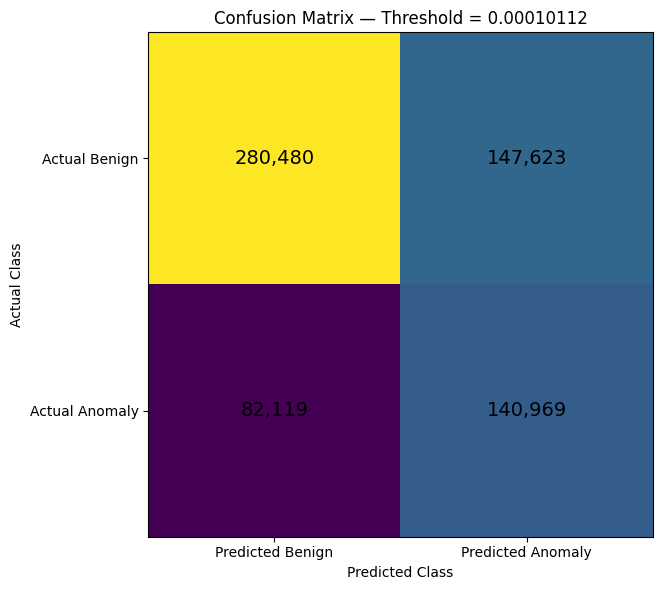

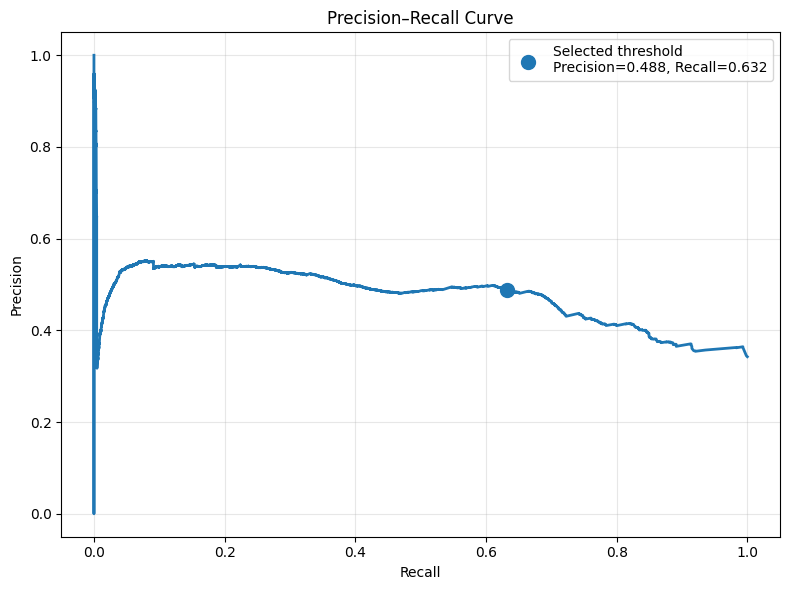

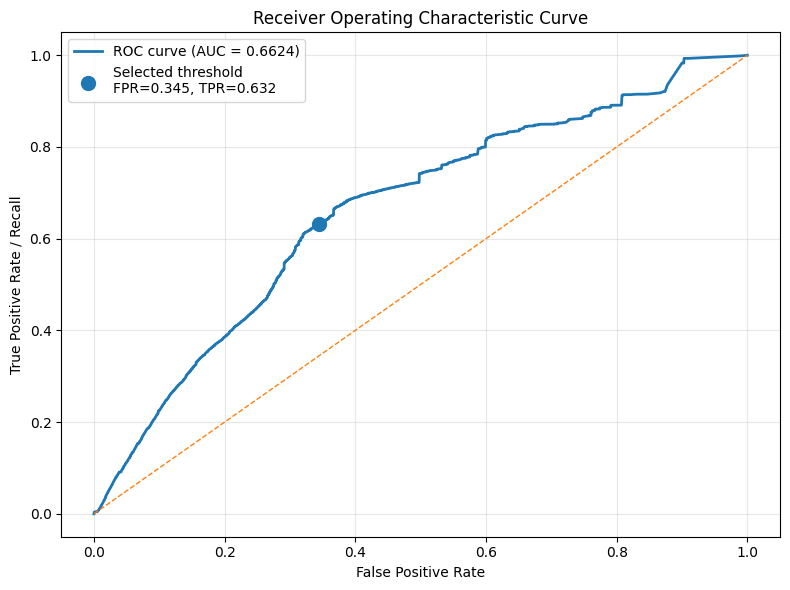

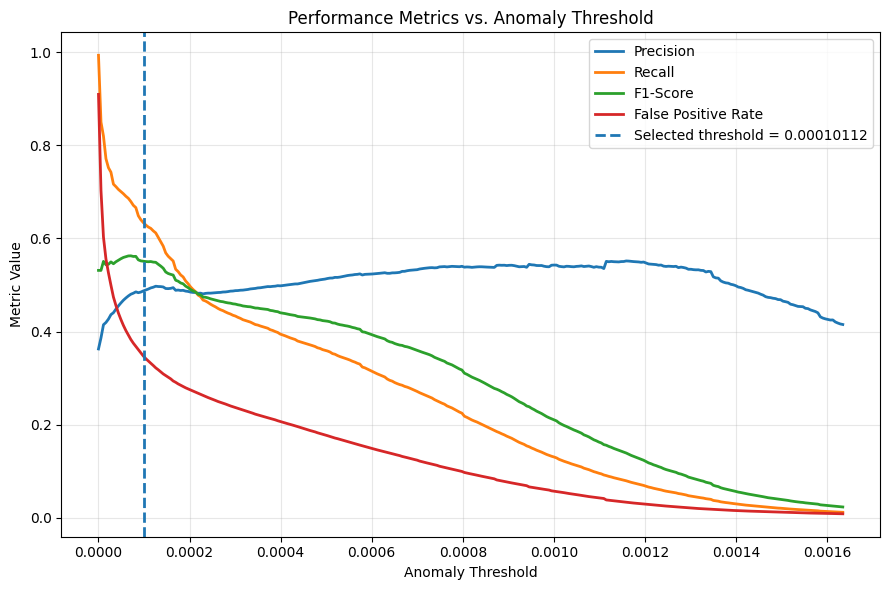

SELECTED THRESHOLD PERFORMANCE
Threshold : 0.00010112
Precision : 0.4885
Recall    : 0.6319
F1-Score  : 0.5510
FPR       : 0.3448
AUC       : 0.6624

Confusion Matrix:
TN = 280,480
FP = 147,623
FN = 82,119
TP = 140,969


In [ ]:
# ============================================================
# VISUAL EVALUATION OF THE SELECTED THRESHOLD
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    auc
)

# ------------------------------------------------------------
# Selected threshold
# ------------------------------------------------------------

SELECTED_THRESHOLD = 0.00010112

y_pred_selected = (
    reconstruction_errors > SELECTED_THRESHOLD
).astype(np.int8)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred_selected,
    labels=[0, 1]
).ravel()

# Metrics
precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) else 0
)
fpr = fp / (fp + tn) if (fp + tn) else 0

# ============================================================
# FIGURE 1 — CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

cm = np.array([
    [tn, fp],
    [fn, tp]
])

im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Predicted Benign", "Predicted Anomaly"])
ax.set_yticklabels(["Actual Benign", "Actual Anomaly"])

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

ax.set_title(
    f"Confusion Matrix — Threshold = {SELECTED_THRESHOLD:.8f}"
)

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            fontsize=14
        )

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2 — PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        y_true,
        reconstruction_errors
    )
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    recall_curve,
    precision_curve,
    linewidth=2
)

# Mark selected operating point
ax.scatter(
    recall,
    precision,
    s=100,
    zorder=5,
    label=(
        f"Selected threshold\n"
        f"Precision={precision:.3f}, "
        f"Recall={recall:.3f}"
    )
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curve")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 3 — ROC CURVE
# ============================================================

fpr_curve, tpr_curve, roc_thresholds = roc_curve(
    y_true,
    reconstruction_errors
)

roc_auc = auc(
    fpr_curve,
    tpr_curve
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    fpr_curve,
    tpr_curve,
    linewidth=2,
    label=f"ROC curve (AUC = {roc_auc:.4f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

# Mark selected threshold
ax.scatter(
    fpr,
    recall,
    s=100,
    zorder=5,
    label=(
        f"Selected threshold\n"
        f"FPR={fpr:.3f}, TPR={recall:.3f}"
    )
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Recall")
ax.set_title("Receiver Operating Characteristic Curve")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 4 — METRICS VS THRESHOLD
# ============================================================

thresholds = np.linspace(
    np.percentile(reconstruction_errors, 1),
    np.percentile(reconstruction_errors, 99),
    300
)

precision_values = []
recall_values = []
f1_values = []
fpr_values = []

for threshold_test in thresholds:

    pred = (
        reconstruction_errors > threshold_test
    ).astype(np.int8)

    tn_t, fp_t, fn_t, tp_t = confusion_matrix(
        y_true,
        pred,
        labels=[0, 1]
    ).ravel()

    p = (
        tp_t / (tp_t + fp_t)
        if (tp_t + fp_t) else 0
    )

    r = (
        tp_t / (tp_t + fn_t)
        if (tp_t + fn_t) else 0
    )

    f = (
        2 * p * r / (p + r)
        if (p + r) else 0
    )

    fp_rate = (
        fp_t / (fp_t + tn_t)
        if (fp_t + tn_t) else 0
    )

    precision_values.append(p)
    recall_values.append(r)
    f1_values.append(f)
    fpr_values.append(fp_rate)

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    thresholds,
    precision_values,
    label="Precision",
    linewidth=2
)

ax.plot(
    thresholds,
    recall_values,
    label="Recall",
    linewidth=2
)

ax.plot(
    thresholds,
    f1_values,
    label="F1-Score",
    linewidth=2
)

ax.plot(
    thresholds,
    fpr_values,
    label="False Positive Rate",
    linewidth=2
)

ax.axvline(
    SELECTED_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=f"Selected threshold = {SELECTED_THRESHOLD:.8f}"
)

ax.set_xlabel("Anomaly Threshold")
ax.set_ylabel("Metric Value")
ax.set_title("Performance Metrics vs. Anomaly Threshold")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 65)
print("SELECTED THRESHOLD PERFORMANCE")
print("=" * 65)

print(f"Threshold : {SELECTED_THRESHOLD:.8f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"FPR       : {fpr:.4f}")
print(f"AUC       : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(f"TN = {tn:,}")
print(f"FP = {fp:,}")
print(f"FN = {fn:,}")
print(f"TP = {tp:,}")